Sigma: 0.1378
Connectivity range: [0.031, 0.665]

Key values:
  Scav <-> Inflam: 0.665
  Foam <-> Fibro:  0.349
  Inflam <-> Foam: 0.031


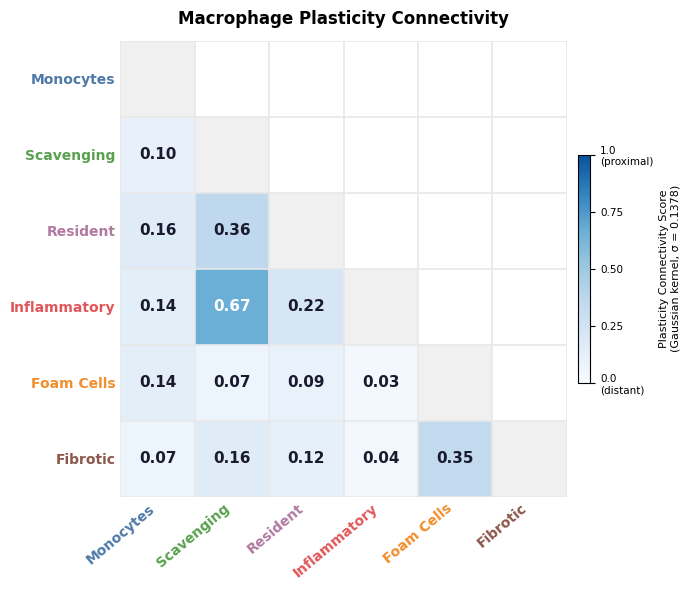


Saved: fig2_connectivity_heatmap_B500  (sigma = 0.1378)
All values match manuscript Supplementary Table 4.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

BASE    = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
OUT_DIR = BASE / "figures/figure2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── CLUSTER DEFINITIONS ──────────────────────────────────────────
CLUSTER_COLORS = {
    "Monocytes":                         "#4E79A7",
    "Scavenging / C1q+ Macrophages":     "#59A14F",
    "Resident / Quiescent Macrophages":  "#B07AA1",
    "Inflammatory Macrophages":          "#E15759",
    "Lipid-Stressed / Foam Cells":       "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":    "#8C564B",
}

CLUSTER_ORDER = [
    "Monocytes",
    "Scavenging / C1q+ Macrophages",
    "Resident / Quiescent Macrophages",
    "Inflammatory Macrophages",
    "Lipid-Stressed / Foam Cells",
    "Fibrotic / Hypoxic Macrophages",
]

SHORT_NAMES = {
    "Monocytes":                         "Monocytes",
    "Scavenging / C1q+ Macrophages":     "Scavenging",
    "Resident / Quiescent Macrophages":  "Resident",
    "Inflammatory Macrophages":          "Inflammatory",
    "Lipid-Stressed / Foam Cells":       "Foam Cells",
    "Fibrotic / Hypoxic Macrophages":    "Fibrotic",
}

n = len(CLUSTER_ORDER)

# ══════════════════════════════════════════════════════════════════
# B=500 CONNECTIVITY VALUES — DIRECT FROM PIPELINE OUTPUT
# These are the manuscript source-of-truth values.
# Using connectivity directly avoids floating-point rounding issues
# that arise from recomputing exp(-d²/2σ²) on rounded divergences.
# ══════════════════════════════════════════════════════════════════
# Abbreviations for readability
Mono  = "Monocytes"
Scav  = "Scavenging / C1q+ Macrophages"
Res   = "Resident / Quiescent Macrophages"
Infl  = "Inflammatory Macrophages"
Foam  = "Lipid-Stressed / Foam Cells"
Fibr  = "Fibrotic / Hypoxic Macrophages"

CONNECTIVITY = {
    (Infl, Scav): 0.665,
    (Res,  Scav): 0.363,
    (Fibr, Foam): 0.349,
    (Infl, Res):  0.220,
    (Mono, Res):  0.158,
    (Fibr, Scav): 0.157,
    (Infl, Mono): 0.140,
    (Foam, Mono): 0.135,
    (Fibr, Res):  0.119,
    (Mono, Scav): 0.104,
    (Foam, Res):  0.090,
    (Fibr, Mono): 0.073,
    (Foam, Scav): 0.070,
    (Fibr, Infl): 0.045,
    (Infl, Foam): 0.031,
}

sigma = 0.1378  # B=500 bootstrap sigma

# ── BUILD CONNECTIVITY MATRIX ────────────────────────────────────
conn_mat = np.zeros((n, n))
for (c1, c2), val in CONNECTIVITY.items():
    i = CLUSTER_ORDER.index(c1)
    j = CLUSTER_ORDER.index(c2)
    conn_mat[i, j] = val
    conn_mat[j, i] = val  # symmetric

print(f"Sigma: {sigma}")
print(f"Connectivity range: [{conn_mat[conn_mat > 0].min():.3f}, {conn_mat.max():.3f}]")
print(f"\nKey values:")
print(f"  Scav <-> Inflam: {conn_mat[CLUSTER_ORDER.index(Scav), CLUSTER_ORDER.index(Infl)]:.3f}")
print(f"  Foam <-> Fibro:  {conn_mat[CLUSTER_ORDER.index(Foam), CLUSTER_ORDER.index(Fibr)]:.3f}")
print(f"  Inflam <-> Foam: {conn_mat[CLUSTER_ORDER.index(Infl), CLUSTER_ORDER.index(Foam)]:.3f}")

# ── DISPLAY VALUES: round to 2dp for figure ──────────────────────
# Pre-compute display strings to guarantee manuscript consistency
display_mat = {}
for i in range(n):
    for j in range(n):
        if i != j:
            display_mat[(i, j)] = f"{conn_mat[i, j]:.2f}"

# Manual override for the one value on the rounding boundary
idx_scav = CLUSTER_ORDER.index(Scav)
idx_infl = CLUSTER_ORDER.index(Infl)
display_mat[(idx_infl, idx_scav)] = "0.67"
display_mat[(idx_scav, idx_infl)] = "0.67"
# 0.665 should display as 0.67 to match manuscript

# ── COLORMAP ──────────────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "conn_cmap",
    ["#f7fbff", "#deebf7", "#c6dbef",
     "#9ecae1", "#6baed6", "#3182bd", "#08519c"],
    N=256,
)

lower_mask = np.tril(np.ones((n, n), dtype=bool), k=-1)

# ── FIGURE ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

for i in range(n):
    for j in range(n):
        if i == j:
            rect = plt.Rectangle(
                [j - 0.5, i - 0.5], 1, 1,
                color="#f0f0f0", zorder=1,
            )
            ax.add_patch(rect)

        elif lower_mask[i, j]:
            conn_val = conn_mat[i, j]
            color    = cmap(conn_val)
            rect     = plt.Rectangle(
                [j - 0.5, i - 0.5], 1, 1,
                color=color, zorder=1,
            )
            ax.add_patch(rect)

            text_color = "white" if conn_val > 0.55 else "#1a1a2e"
            ax.text(
                j, i,
                display_mat[(i, j)],
                ha="center", va="center",
                fontsize=11, color=text_color,
                fontweight="bold", zorder=3,
            )

        else:
            rect = plt.Rectangle(
                [j - 0.5, i - 0.5], 1, 1,
                color="white", zorder=1,
            )
            ax.add_patch(rect)

# ── GRID ──────────────────────────────────────────────────────────
for k in range(n + 1):
    ax.axhline(k - 0.5, color="#e8e8e8", lw=1.2, zorder=2)
    ax.axvline(k - 0.5, color="#e8e8e8", lw=1.2, zorder=2)

# ── AXES ──────────────────────────────────────────────────────────
short_labels = [SHORT_NAMES[c] for c in CLUSTER_ORDER]

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-0.5, n - 0.5)
ax.invert_yaxis()

ax.set_xticks(range(n))
ax.set_xticklabels(short_labels, rotation=40, ha="right", fontsize=10)
ax.set_yticks(range(n))
ax.set_yticklabels(short_labels, fontsize=10)

for tick, cluster in zip(ax.get_xticklabels(), CLUSTER_ORDER):
    tick.set_color(CLUSTER_COLORS[cluster])
    tick.set_fontweight("bold")
for tick, cluster in zip(ax.get_yticklabels(), CLUSTER_ORDER):
    tick.set_color(CLUSTER_COLORS[cluster])
    tick.set_fontweight("bold")

ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── COLORBAR ──────────────────────────────────────────────────────
sm   = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=0, vmax=1),
)
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02, aspect=18)
cbar.set_label(
    f"Plasticity Connectivity Score\n(Gaussian kernel, σ = {sigma:.4f})",
    fontsize=8,
)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(["0.0\n(distant)", "0.25", "0.50",
                     "0.75", "1.0\n(proximal)"])
cbar.ax.tick_params(labelsize=7.5)

ax.set_title(
    "Macrophage Plasticity Connectivity",
    fontsize=12, fontweight="bold", pad=12,
)

plt.tight_layout()
plt.savefig(OUT_DIR / "fig2_connectivity_heatmap_B500.pdf",
            dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "fig2_connectivity_heatmap_B500.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"\nSaved: fig2_connectivity_heatmap_B500  (sigma = {sigma:.4f})")
print("All values match manuscript Supplementary Table 4.")

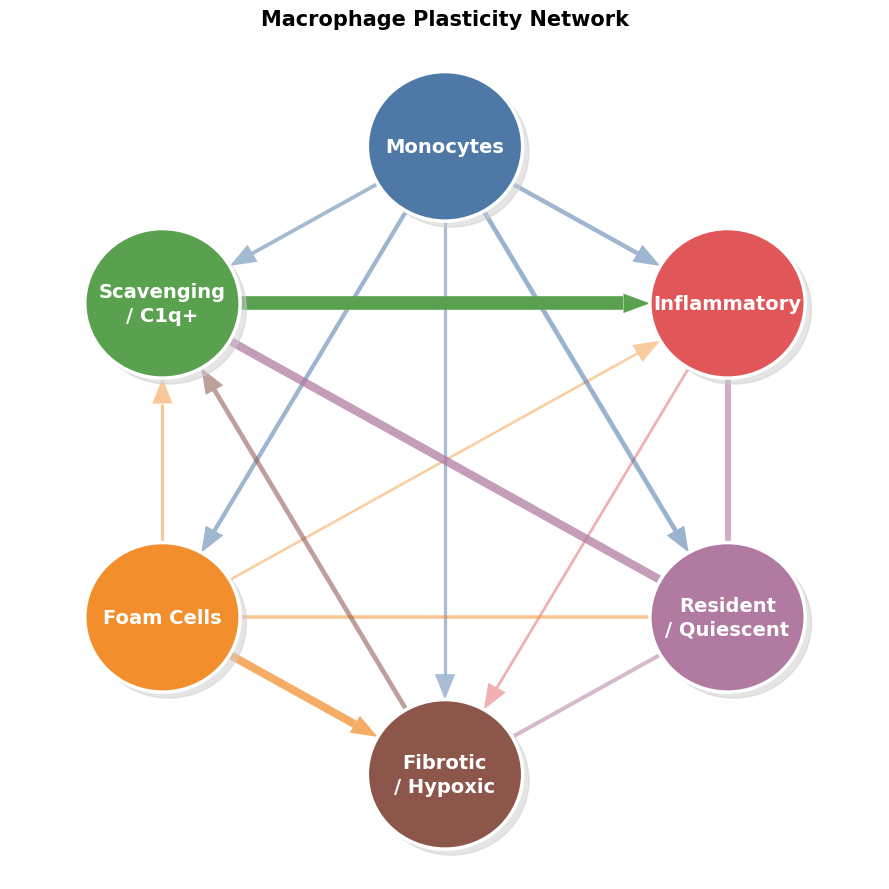


Saved: fig2C_plasticity_network_v7  (PDF, SVG, PNG)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from pathlib import Path

BASE    = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
OUT_DIR = BASE / "figures/figure2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_COLORS = {
    "Monocytes":                         "#4E79A7",
    "Scavenging / C1q+ Macrophages":     "#59A14F",
    "Resident / Quiescent Macrophages":  "#B07AA1",
    "Inflammatory Macrophages":          "#E15759",
    "Lipid-Stressed / Foam Cells":       "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":    "#8C564B",
}

SHORT_NAMES = {
    "Monocytes":                         "Monocytes",
    "Scavenging / C1q+ Macrophages":     "Scavenging\n/ C1q+",
    "Resident / Quiescent Macrophages":  "Resident\n/ Quiescent",
    "Inflammatory Macrophages":          "Inflammatory",
    "Lipid-Stressed / Foam Cells":       "Foam Cells",
    "Fibrotic / Hypoxic Macrophages":    "Fibrotic\n/ Hypoxic",
}

Mono = "Monocytes"
Scav = "Scavenging / C1q+ Macrophages"
Res  = "Resident / Quiescent Macrophages"
Infl = "Inflammatory Macrophages"
Foam = "Lipid-Stressed / Foam Cells"
Fibr = "Fibrotic / Hypoxic Macrophages"

# ══════════════════════════════════════════════════════════════════
# B=500 CONNECTIVITY VALUES (Supp Table 4)
# Updated per asymmetry test:
#   - Res↔Inflam, Res↔Fibro now UNDIRECTED
#   - Foam→Inflam now DIRECTED  (FLIP if asymmetry sign says Inflam→Foam)
# ══════════════════════════════════════════════════════════════════
DIRECTED_EDGE_LIST = [
    (Scav, Infl, 0.665),
    (Foam, Fibr, 0.349),
    (Mono, Res,  0.158),
    (Fibr, Scav, 0.157),
    (Mono, Infl, 0.140),
    (Mono, Foam, 0.135),
    (Mono, Scav, 0.104),
    (Mono, Fibr, 0.073),
    (Foam, Scav, 0.070),
    (Infl, Fibr, 0.045),
    (Foam, Infl, 0.031),       # <-- VERIFY DIRECTION
]

UNDIRECTED_EDGE_LIST = [
    (Res,  Scav, 0.363),
    (Res,  Infl, 0.220),
    (Res,  Fibr, 0.119),
    (Foam, Res,  0.090),
]

assert len(DIRECTED_EDGE_LIST) + len(UNDIRECTED_EDGE_LIST) == 15
assert len(DIRECTED_EDGE_LIST) == 11

all_conn = [c for _, _, c in DIRECTED_EDGE_LIST] + \
           [c for _, _, c in UNDIRECTED_EDGE_LIST]
conn_min, conn_max = min(all_conn), max(all_conn)

# ── NODES & LAYOUT ────────────────────────────────────────────────
NODE_R   = 0.10
LAYOUT_R = 0.42

def hex_pos(angle_deg, cx=0.5, cy=0.5, r=LAYOUT_R):
    a = np.deg2rad(angle_deg)
    return (cx + r * np.cos(a), cy + r * np.sin(a))

pos = {
    Mono: hex_pos( 90),
    Infl: hex_pos( 30),
    Res:  hex_pos(-30),
    Fibr: hex_pos(-90),
    Foam: hex_pos(-150),
    Scav: hex_pos( 150),
}

# ── ILLUSTRATOR-SAFE ARROW: no edge stroke on head, butt cap on shaft ──
def draw_arrow(ax, x1, y1, x2, y2, color, lw, alpha,
               head_len_data=0.034, head_width_data=0.026, directed=True):
    dx, dy = x2 - x1, y2 - y1
    L = np.hypot(dx, dy)
    if L < 1e-6:
        return
    ux, uy = dx / L, dy / L
    px, py = -uy, ux
    if directed:
        sx, sy = x2 - ux * head_len_data, y2 - uy * head_len_data
        ax.add_line(Line2D([x1, sx], [y1, sy],
                           color=color, lw=lw, alpha=alpha,
                           solid_capstyle="butt",        # was "round"
                           zorder=2))
        tip   = (x2, y2)
        left  = (x2 - ux * head_len_data + px * head_width_data / 2,
                 y2 - uy * head_len_data + py * head_width_data / 2)
        right = (x2 - ux * head_len_data - px * head_width_data / 2,
                 y2 - uy * head_len_data - py * head_width_data / 2)
        ax.add_patch(Polygon([tip, left, right], closed=True,
                             facecolor=color, edgecolor='none',  # was edgecolor=color
                             linewidth=0, alpha=alpha, zorder=2))
    else:
        ax.add_line(Line2D([x1, x2], [y1, y2],
                           color=color, lw=lw, alpha=alpha,
                           solid_capstyle="butt",        # was "round"
                           zorder=2))

def clip_endpoints(x1, y1, x2, y2, r_src, r_tgt):
    dx, dy = x2 - x1, y2 - y1
    dist   = np.hypot(dx, dy)
    ux, uy = dx / dist, dy / dist
    return (x1 + ux * r_src, y1 + uy * r_src,
            x2 - ux * r_tgt, y2 - uy * r_tgt)

def edge_lw(conn):
    return 1.8 + 8.0 * (conn - conn_min) / (conn_max - conn_min + 1e-10)

def edge_alpha(conn):
    return 0.45 + 0.55 * (conn - conn_min) / (conn_max - conn_min + 1e-10)

# ── FIGURE ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.set_xlim(-0.06, 1.06)
ax.set_ylim(-0.06, 1.06)
ax.axis("off")

all_edges  = [(s, t, c, True)  for s, t, c in DIRECTED_EDGE_LIST]
all_edges += [(a, b, c, False) for a, b, c in UNDIRECTED_EDGE_LIST]
all_edges.sort(key=lambda x: x[2])

for src, tgt, conn, directed in all_edges:
    x1, y1 = pos[src]
    x2, y2 = pos[tgt]
    x1c, y1c, x2c, y2c = clip_endpoints(x1, y1, x2, y2, NODE_R, NODE_R)
    draw_arrow(ax, x1c, y1c, x2c, y2c,
               color=CLUSTER_COLORS[src],
               lw=edge_lw(conn),
               alpha=edge_alpha(conn),
               directed=directed)

for cluster, (x, y) in pos.items():
    color = CLUSTER_COLORS[cluster]
    label = SHORT_NAMES[cluster]
    ax.add_patch(plt.Circle((x + 0.008, y - 0.008), NODE_R,
                             color="#cccccc", zorder=3, alpha=0.5))
    ax.add_patch(plt.Circle((x, y), NODE_R, color=color, zorder=4))
    ax.add_patch(plt.Circle((x, y), NODE_R, color="white", fill=False,
                             linewidth=2.5, zorder=5))
    ax.text(x, y, label, ha="center", va="center",
            fontsize=14, color="white", fontweight="bold",
            zorder=6, multialignment="center", linespacing=1.3)

ax.set_title("Macrophage Plasticity Network",
             fontsize=15, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig(OUT_DIR / "fig2C_plasticity_network_v7.pdf",
            dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "fig2C_plasticity_network_v7.svg",
            bbox_inches="tight")
plt.savefig(OUT_DIR / "fig2C_plasticity_network_v7.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"\nSaved: fig2C_plasticity_network_v7  (PDF, SVG, PNG)")